In [1]:
import os
from os.path import join
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'AUPRC']
STRATEGIES = ['avg', 'vote', 'mil']
STRATEGY_COLORS = {'avg': 'blue', 'vote': 'orange', 'mil': 'green'}
RESULTS_PATH = os.path.expanduser('~/scFM_eval/results/classification.metrics.csv')
PLOTS_DIR = './plots'


In [3]:
def process_and_sort(df):
    """Sort models by group then mean metric, matching Fig4_a."""
    model_means = df.groupby('experiment')['mean'].mean().reset_index(name='mean_overall')
    model_groups = df[['experiment', 'group']].drop_duplicates()
    sorted_models = model_means.merge(model_groups, on='experiment')
    sorted_models = sorted_models.sort_values(by=['group', 'mean_overall'], ascending=[True, False])
    return sorted_models


def get_fig4a_model_order(df, strategy='avg', sort_metric='AUPRC'):
    """Return model_display names ordered like Fig4_a (group, then descending AUPRC)."""
    subset = df[df.strategy == strategy]
    dd = (
        subset.groupby(['exp_display', 'group', 'model_display', 'strategy'])[sort_metric]
        .mean()
        .reset_index()
    )
    dd['mean'] = dd[sort_metric]
    dd['experiment'] = dd['model_display']
    sorted_models = process_and_sort(dd)
    return sorted_models['experiment'].tolist(), sorted_models


In [4]:
def plot_classification_radar(mean_vals, std_vals, metric_labels, model='HVG'):
    """Plot a single-model radar chart with outward error bars and an ideal reference."""
    num_vars = len(metric_labels)

    def close_circle(values):
        return values.tolist() + values.tolist()[:1]

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    mean_values = close_circle(mean_vals)
    reference_values = close_circle(np.ones(num_vars))

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, reference_values, label='Reference (Ideal)', linewidth=2, color='gray', linestyle='--')
    ax.plot(angles, mean_values, label=model, linewidth=2, color='blue')
    ax.scatter(angles, mean_values, color='blue', s=50)

    for i in range(num_vars):
        ax.vlines(angles[i], mean_vals[i], min(1.0, mean_vals[i] + std_vals[i]), color='blue', linewidth=1.5)

    ax.set_title(f'Classification Metrics of {model}', size=16)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_rlabel_position(30)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='grey', size=10)
    ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True, color='lightgray')
    ax.xaxis.grid(True, color='lightgray')
    for spine in ax.spines.values():
        spine.set_color('gray')
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_classification_radar_subplot_with_values_below(ax, mean_vals, std_vals, metric_labels, title='', color='blue'):
    """Subplot radar chart with mean/std annotated below metric names."""
    num_vars = len(metric_labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    def close_circle(values):
        return values.tolist() + values.tolist()[:1]

    mean_values = close_circle(mean_vals)
    reference_values = close_circle(np.ones(num_vars))

    ax.plot(angles, reference_values, linewidth=1.5, color='gray', linestyle='--')
    ax.plot(angles, mean_values, linewidth=1.5, color=color)
    ax.scatter(angles, mean_values, color=color, s=20)

    for i in range(num_vars):
        ax.vlines(angles[i], mean_vals[i], min(1.0, mean_vals[i] + std_vals[i]), color=color, linewidth=1)

    ax.set_xticks(angles[:-1])
    xtick_labels = [f"{label}\n {mean_vals[i]:.2f}, {std_vals[i]:.2f}" for i, label in enumerate(metric_labels)]
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_yticks([0.2, 0.6, 1.0])
    ax.set_yticklabels(['0.2', '0.6', '1.0'], color='grey', size=7)
    ax.set_ylim(0, 1.05)
    ax.set_rlabel_position(0)
    ax.grid(color='lightgray')
    for spine in ax.spines.values():
        spine.set_color('gray')
    ax.set_title(title, fontsize=10)


def plot_radar_grid(df, models, strategy, color='blue', save_path=None, suptitle=None):
    """Plot one radar per model in a grid, using Fig4_a model order."""
    n_models = len(models)
    ncols = 3
    nrows = int(np.ceil(n_models / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.6 * nrows), subplot_kw=dict(polar=True))
    axes_flat = np.atleast_1d(axes).flat

    for ax, model in zip(axes_flat, models):
        dd = df[(df.model_display == model) & (df.strategy == strategy)]
        means = dd[METRIC_COLS].mean()
        stds = dd[METRIC_COLS].std()
        plot_classification_radar_subplot_with_values_below(ax, means, stds, METRIC_COLS, title=model, color=color)

    for ax in list(axes_flat)[n_models:]:
        ax.set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.02)
    fig.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [5]:
df = pd.read_csv(RESULTS_PATH)
df['strategy'] = df['strategy'].str.lower()  # CSV uses 'MIL'; normalize to 'mil'

exclude = (
    df.model_display.str.contains('continue')
    | df.model_display.str.contains('Full')
    | df.model_display.str.contains('finetune')
    | df.model_display.isin(['PCA [100]', 'PCA [50]'])
)
df = df.loc[~exclude].copy()
df.strategy.value_counts()


strategy
vote    510
mil     510
avg     510
Name: count, dtype: int64

In [6]:
model_order, sorted_models = get_fig4a_model_order(df, strategy='avg', sort_metric='AUPRC')
sorted_models.round(2)


,experiment,mean_overall,group
5,HVG,0.90,Baseline
14,scVI,0.87,Baseline
7,PCA [20],0.77,Baseline
3,GF-V2 [cancer],0.88,Geneformer
4,GF-V2-Deep,0.86,Geneformer
2,GF-V2,0.85,Geneformer
1,GF-V1,0.84,Geneformer
8,SCimiarity,0.88,Other
9,STATE,0.87,Other
11,scFoundation,0.86,Other


/tmp/ipykernel_133739/516084071.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.vlines(angles[i], mean_vals[i], min(1.0, mean_vals[i] + std_vals[i]), color='blue', linewidth=1.5)


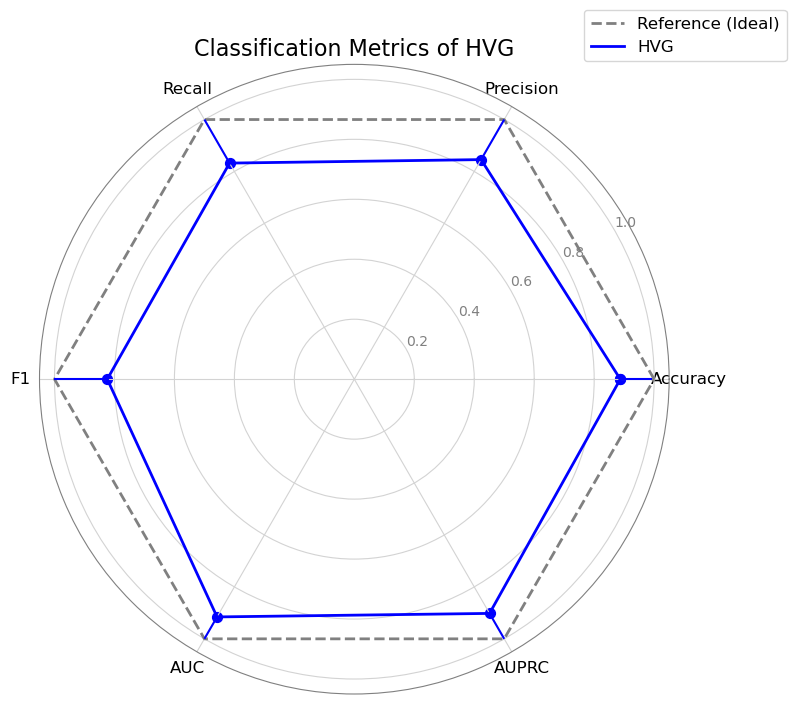

In [7]:
# Example: single-model radar (HVG, avg aggregation)
dd = df[(df.model_display == 'HVG') & (df.strategy == 'avg')]
means = dd[METRIC_COLS].mean()
stds = dd[METRIC_COLS].std()
plot_classification_radar(means, stds, METRIC_COLS, model='HVG')


/tmp/ipykernel_133739/516084071.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.vlines(angles[i], mean_vals[i], min(1.0, mean_vals[i] + std_vals[i]), color=color, linewidth=1)
/tmp/ipykernel_133739/516084071.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xtick_labels = [f"{label}\n {mean_vals[i]:.2f}, {std_vals[i]:.2f}" for i, label in enumerate(metric_labels)]
/tmp/ipykernel_133739/516084071.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

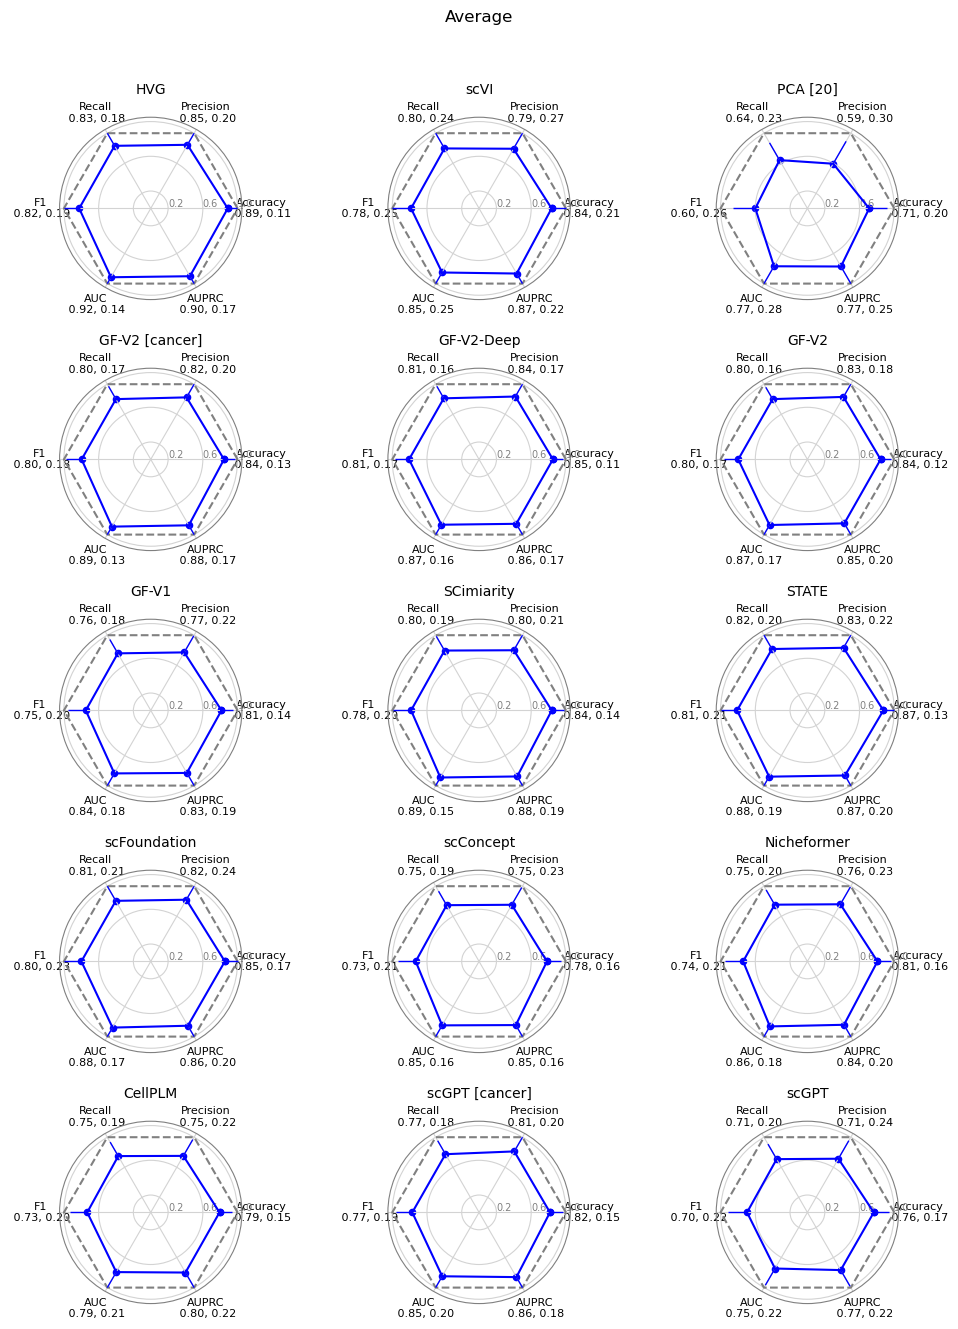

In [8]:
plot_radar_grid(
    df,
    model_order,
    strategy='avg',
    color='blue',
    save_path=join(PLOTS_DIR, 'fig5_avg_radar.png'),
    suptitle='Average',
)


/tmp/ipykernel_133739/516084071.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.vlines(angles[i], mean_vals[i], min(1.0, mean_vals[i] + std_vals[i]), color=color, linewidth=1)
/tmp/ipykernel_133739/516084071.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xtick_labels = [f"{label}\n {mean_vals[i]:.2f}, {std_vals[i]:.2f}" for i, label in enumerate(metric_labels)]
/tmp/ipykernel_133739/516084071.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

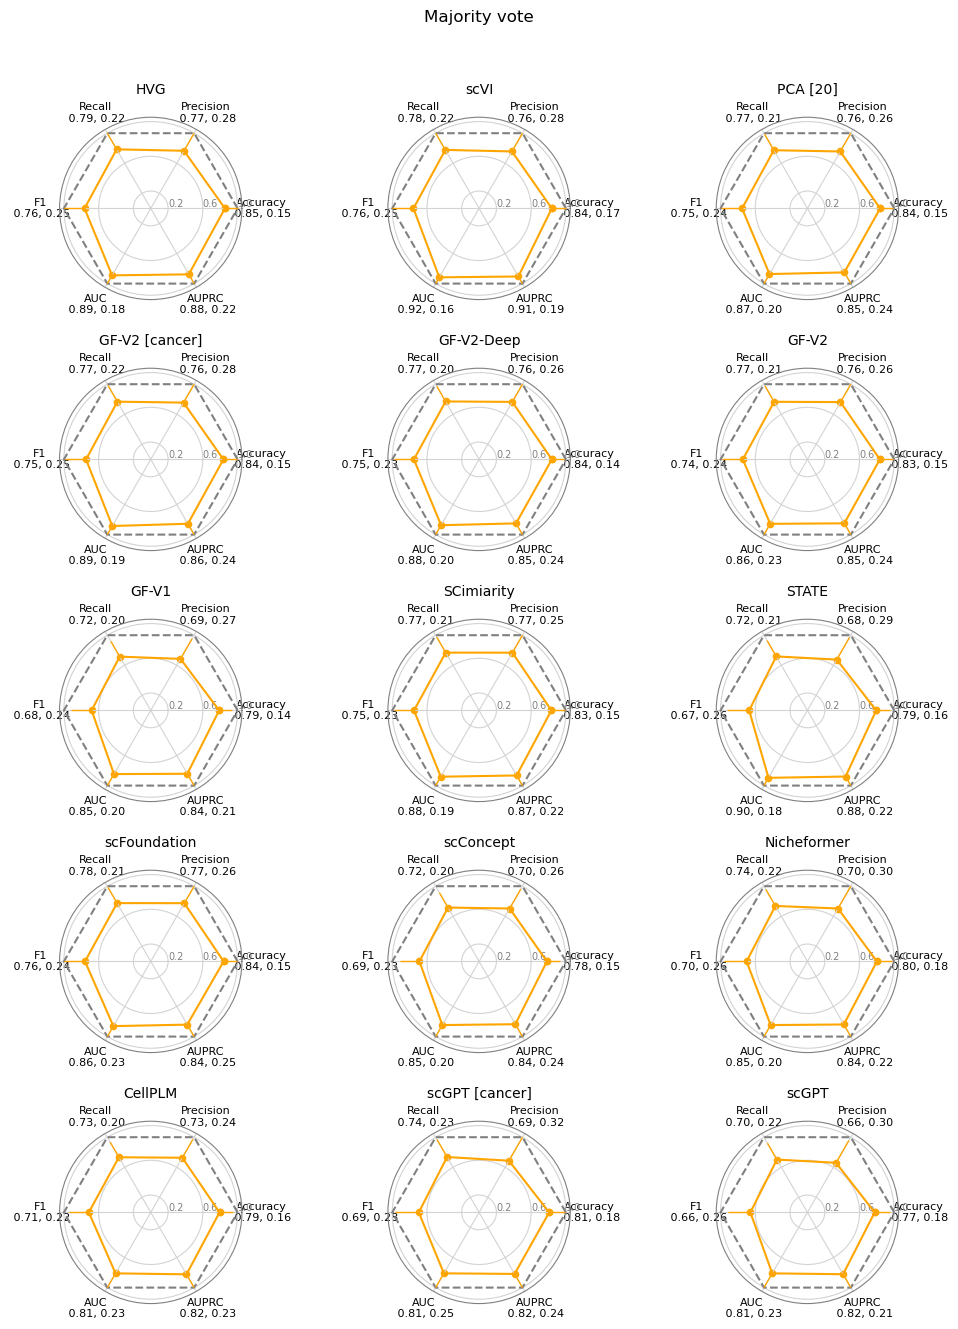

In [9]:
plot_radar_grid(
    df,
    model_order,
    strategy='vote',
    color='orange',
    save_path=join(PLOTS_DIR, 'fig5_vote_radar.png'),
    suptitle='Majority vote',
)


/tmp/ipykernel_133739/516084071.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.vlines(angles[i], mean_vals[i], min(1.0, mean_vals[i] + std_vals[i]), color=color, linewidth=1)
/tmp/ipykernel_133739/516084071.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xtick_labels = [f"{label}\n {mean_vals[i]:.2f}, {std_vals[i]:.2f}" for i, label in enumerate(metric_labels)]
/tmp/ipykernel_133739/516084071.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

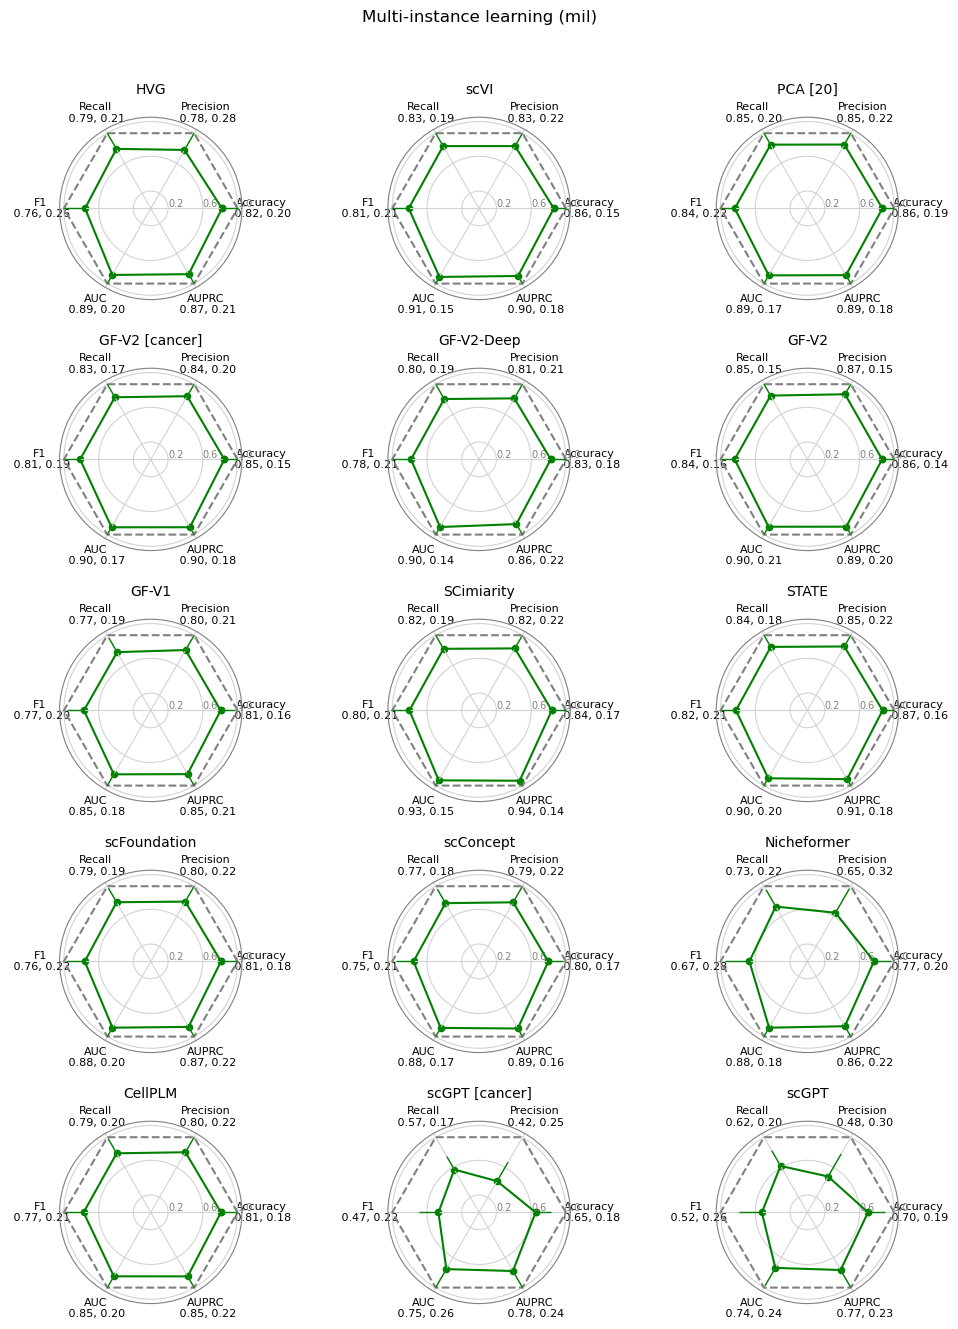

In [10]:
plot_radar_grid(
    df,
    model_order,
    strategy='mil',
    color='green',
    save_path=join(PLOTS_DIR, 'fig5_mil_radar.png'),
    suptitle='Multi-instance learning (mil)',
)
